# Analiza Koszykowa Sprzedaży Krzyżowej dla Sieci Spożywczej z PROC MBANALYSIS


## Podsumowanie Wykonawcze

Regionalna sieć sklepów spożywczych analizuje sezon koszyków z punktów sprzedaży (POS), aby odkryć, które produkty klienci kupują razem, zamieniając surowe dzienniki transakcji w konkretne decyzje dotyczące sprzedaży krzyżowej i rozmieszczenia towaru na półkach. PROC MBANALYSIS skanuje dziennik transakcji i generuje reguły asocjacyjne oceniane wg wsparcia (support), ufności (confidence) i lift. Uruchomienie na 51 syntetycznych koszykach odtwarza dokładnie trzy zaplanowane powiązania produktowe — `Spaghetti -> Sos Marinara` (ufność 0,93, lift 3,4), `Skorupki Taco -> Salsa` (ufność 0,71, lift 3,6) oraz `Kawa -> Śmietanka do Kawy` (ufność 0,70, lift 5,1) — podczas gdy powszechnie kupowane produkty podstawowe, jak chleb, mleko i jajka, nigdy nie tworzą reguły. Każda ujawniona para to podręcznikowy kandydat na zestaw promocyjny, sąsiedztwo na półce oraz rekomendację typu "klienci kupili także" dla zespołu merchandisingu.


## Źródła Danych

| Zbiór danych | Ziarnistość | Wiersze | Kluczowe zmienne | Opis |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Jeden wiersz na produkt w koszyku | 100 wierszy produktów w 51 koszykach | `basket_id` (identyfikator transakcji), `item` (nazwa produktu, $20) | Syntetyczny dziennik POS wygenerowany w locie za pomocą `call streaminit(20250529)` i `rand('uniform')`. W każdym koszyku dominuje jedna persona kupującego, dzięki czemu wzorce współzakupów pozostają czytelne i łatwe do interpretacji: koszyk "kolacja włoska" (spaghetti -> sos marinara), koszyk "wieczór tacos" (skorupki taco -> salsa) lub koszyk śniadaniowy (kawa -> śmietanka do kawy), plus okazjonalne dodatki podstawowe (chleb, mleko, jajka) jako realistyczny szum. W tym nielicencjonowanym środowisku silnik ogranicza dane wyjściowe do 100 wierszy produktów, co tutaj obejmuje koszyki 1-51. |
| `affinity_rules` | Jeden wiersz na regułę asocjacyjną | 6 reguł | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Reguły asocjacyjne wygenerowane przez `OUTPUT RULES=`; podstawa do rankingu szans sprzedaży krzyżowej. |
| `frequent_items` | Jeden wiersz na częsty zbiór | 12 zbiorów | `itemset`, `support`, `length` | Częste zbiory produktów wygenerowane przez `OUTPUT ITEMS=`; 9 pojedynczych produktów plus 3 pary produktów, które przekraczają próg minimalnego wsparcia. |


# Analiza Koszykowa Sprzedaży Krzyżowej dla Sieci Spożywczej

**Pytanie biznesowe.** Które produkty nasi klienci mają tendencję kupować *razem*, i które z tych wzorców współzakupów są na tyle silne, by na nich działać? Regionalna sieć spożywcza chce zaprojektować promocje pakietowe, zoptymalizować sąsiedztwo produktów na półkach i zasilić rekomendację "klienci kupili także" w swoim sklepie internetowym.

**Metoda.** Używamy **PROC MBANALYSIS**, która wykonuje analizę koszykową za pomocą algorytmu wzrostu wzorców częstych (FP-growth). Skanuje dziennik transakcji, znajduje często współwystępujące zbiory produktów i generuje *reguły asocjacyjne* postaci `Antecedent -> Consequent`, oceniane trzema klasycznymi miarami:

- **Support (wsparcie)** — odsetek wszystkich koszyków zawierających pełną regułę (jak powszechny jest wzorzec).
- **Confidence (ufność)** — `P(Consequent | Antecedent)`, warunkowe prawdopodobieństwo zakupu (jak wiarygodna jest reguła).
- **Lift** — obserwowane wsparcie podzielone przez wsparcie oczekiwane, gdyby obie strony były niezależne. Lift > 1 oznacza, że produkty występują razem *częściej* niż przypadek; im wyższy lift, tym silniejsze powiązanie.

Wygenerujemy realistyczny syntetyczny dziennik POS, uruchomimy MBANALYSIS i uszeregujemy powstałe reguły, aby znaleźć najlepsze okazje sprzedaży krzyżowej.


## Krok 1 — Wygeneruj syntetyczny dziennik transakcji punktu sprzedaży

MBANALYSIS oczekuje **danych na poziomie transakcji (długi format)**: jeden wiersz na produkt, oznaczony koszykiem, do którego należy. Budujemy koszyki w locie za pomocą `call streaminit` dla powtarzalności i `rand('uniform')`, aby sterować decyzjami zakupowymi.

Kluczowym wyborem modelowym jest to, że **każdy koszyk jest zdominowany przez jedną personę kupującego**. Prawdziwe wizyty w sklepie spożywczym tak właśnie wyglądają — szybkie zakupy na wieczór tacos, dedykowane uzupełnienie zapasów na śniadanie — a utrzymanie koszyków małych i tematycznych pozwala algorytmowi asocjacyjnemu ujawnić czyste, parowe powiązania zamiast kombinatorycznej eksplozji fałszywych reguł wieloproduktowych. Jedno losowanie `rand('uniform')` na koszyk wybiera personę:

- **Kupujący na kolację włoską** — kupuje spaghetti, potem zwykle sos marinara.
- **Kupujący na wieczór tacos** — kupuje skorupki taco, potem zwykle salsa.
- **Kupujący śniadaniowy** — kupuje kawę, potem zwykle śmietankę do kawy.
- **Zakup wyłącznie podstawowy** — pojedynczy zakup chleba, mleka lub jajek.

Ostatnie losowanie o niskim prawdopodobieństwie dodaje jeden produkt podstawowy do dowolnego koszyka jako realistyczny szum, więc nie każde współwystąpienie jest znaczące. Każda instrukcja `output` zapisuje jeden wiersz produktu, więc pojedynczy koszyk obejmuje kilka wierszy dzielących ten sam `basket_id`. To nielicencjonowane środowisko ogranicza zbiór danych do 100 wierszy produktów, co tutaj obejmuje koszyki od 1 do 51.


In [1]:
DANE store_transactions;
    CALL streaminit(20250529);
    DŁUGOŚĆ item $24;

    POWTÓRZ basket_id = 1 TO 60;

        /* One draw selects the dominant persona for this basket */
        r = rand('uniform');

        /* Italian-dinner basket: spaghetti -> marinara sauce */
        JEŚLI r < 0.30 WTEDY POWTÓRZ;
            item = 'Spaghetti';                          WYJŚCIE;
            JEŚLI rand('uniform') < 0.85 WTEDY POWTÓRZ;
                item = 'Sos Marinara';                    WYJŚCIE;
            KONIEC;
        KONIEC;

        /* Taco-night basket: taco shells -> salsa */
        PRZECIWNIE JEŚLI r < 0.55 WTEDY POWTÓRZ;
            item = 'Skorupki Taco';                       WYJŚCIE;
            JEŚLI rand('uniform') < 0.80 WTEDY POWTÓRZ;
                item = 'Salsa';                           WYJŚCIE;
            KONIEC;
        KONIEC;

        /* Breakfast basket: coffee -> coffee creamer */
        PRZECIWNIE JEŚLI r < 0.78 WTEDY POWTÓRZ;
            item = 'Kawa';                                WYJŚCIE;
            JEŚLI rand('uniform') < 0.75 WTEDY POWTÓRZ;
                item = 'Śmietanka do Kawy';                WYJŚCIE;
            KONIEC;
        KONIEC;

        /* Staples-only trip */
        PRZECIWNIE POWTÓRZ;
            JEŚLI rand('uniform') < 0.34 WTEDY POWTÓRZ;
                item = 'Chleb';                           WYJŚCIE;
            KONIEC;
            PRZECIWNIE JEŚLI rand('uniform') < 0.5 WTEDY POWTÓRZ;
                item = 'Mleko';                           WYJŚCIE;
            KONIEC;
            PRZECIWNIE POWTÓRZ;
                item = 'Jajka';                           WYJŚCIE;
            KONIEC;
        KONIEC;

        /* Occasional staple add-on (realistic noise) */
        JEŚLI rand('uniform') < 0.25 WTEDY POWTÓRZ;
            u = rand('uniform');
            JEŚLI      u < 0.34 WTEDY item = 'Chleb';
            PRZECIWNIE JEŚLI u < 0.67 WTEDY item = 'Mleko';
            PRZECIWNIE                  item = 'Jajka';
            WYJŚCIE;
        KONIEC;

    KONIEC;

    ZACHOWAJ basket_id item;
WYKONAJ;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Krok 2 — Zbadaj surowy dziennik transakcji

Przed eksploracją danych potwierdź, że dane mają oczekiwany długi kształt: kilka wierszy na koszyk, każdy niosący jeden produkt. Wypisujemy pierwsze kilka koszyków i tabelujemy ogólną częstość produktów za pomocą PROC FREQ, aby wiedzieć, które produkty są wystarczająco powszechne, by zakotwiczyć reguły.



  Obs  ID Koszyka        Produkt
-----  ----------  -------------
    1           1  Skorupki Taco
    2           1  Salsa
    3           1  Jajka
    4           2  Skorupki Taco
    5           2  Jajka
    6           3  Kawa
    7           4  Skorupki Taco
    8           5  Jajka
    9           6  Spaghetti
   10           6  Sos Marinara
   11           6  Jajka
   12           7  Skorupki Taco

... 88 more observations (showing 12 of 100)

                                            Ogólna Częstość Zakupu Produktów                                            

                                                   The FREQ Procedure

item                  Frequency    Percent
-------------------------------------------
Spaghetti                    15     15.00
Skorupki Taco                14     14.00
Sos Marinara                 14     14.00
Jajka                        12     12.00
Chleb                        10     10.00
Kawa                         10     10.00
Salsa       


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


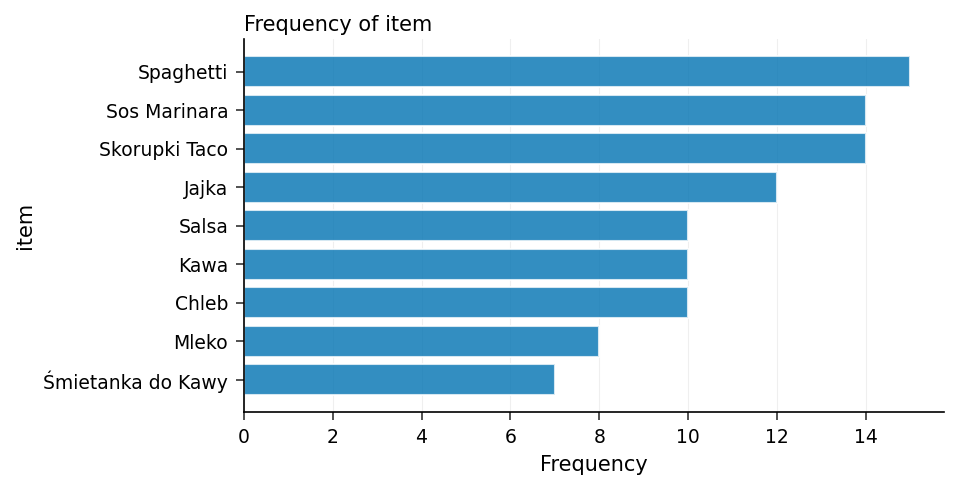

In [2]:
PROCEDURA DRUKUJ DANE=store_transactions(obs=12) ETYKIETA;
    ETYKIETA basket_id = 'ID Koszyka'
          item      = 'Produkt';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=store_transactions ORDER=CZĘSTOŚCI;
    TABLES item / nocum;
    TYTUŁ 'Ogólna Częstość Zakupu Produktów';
WYKONAJ;


## Krok 3 — Wydobądź reguły asocjacyjne za pomocą PROC MBANALYSIS

Teraz właściwa analiza. Kierujemy MBANALYSIS na dziennik transakcji i deklarujemy, która kolumna identyfikuje koszyk (`TRANSACTION`), a która zawiera produkt (`ITEM`). Trzy progi utrzymują zestaw reguł skupiony na wzorcach wartych działania:

- `MINSUPPORT=0.10` — reguła musi pojawić się w co najmniej 10% koszyków, odfiltrowując rzadkie zbiegi okoliczności.
- `MINCONFIDENCE=0.50` — biorąc pod uwagę antecedent, consequent musi wystąpić co najmniej połowę czasu.
- `MINLIFT=1.20` — zachowaj tylko reguły co najmniej 20% silniejsze niż przypadek, abyśmy ujawniali prawdziwe powiązania, a nie artefakty popularnych produktów podstawowych.

Instrukcja `OUTPUT` przechwytuje wygenerowane reguły i częste zbiory produktów do zbiorów danych do dalszego rankingu.


In [3]:
PROCEDURA mbanalysis DANE=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    WYJŚCIE rules=affinity_rules items=frequent_items;
    TYTUŁ 'Reguły Asocjacyjne Koszyka Zakupowego';
WYKONAJ;


                                            Ogólna Częstość Zakupu Produktów                                            


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Kawa                           Śmietanka do Kawy                  0.1373     0.7000     5.1000
  Śmietanka do Kawy              Kawa                               0.1373     1.0000     5.1000
  Salsa                          Skorupki Taco                      0.1961     1.0000     3.6429
  Skorupki Tac


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Krok 4 — Uszereguj okazje sprzedaży krzyżowej wg lift

Zestawienie MBANALYSIS pokazuje każdą kwalifikującą się regułę, ale zespół merchandisingu chce najpierw *najsilniejsze* powiązania. Sortujemy przechwycony zbiór `affinity_rules` malejąco wg lift (a następnie confidence jako kryterium rozstrzygające) i drukujemy najlepsze reguły. Reguła taka jak `Skorupki Taco -> Salsa` z wysokim lift i wysoką ufnością to podręcznikowy kandydat na zestaw: umieść produkty razem lub automatycznie zaproponuj salsę, gdy klient doda skorupki taco online.


In [4]:
PROCEDURA SORTUJ DANE=affinity_rules out=rules_by_lift;
    WEDŁUG MALEJĄCO lift MALEJĄCO confidence;
WYKONAJ;

PROCEDURA DRUKUJ DANE=rules_by_lift(obs=15) ETYKIETA;
    ZMIENNA antecedent consequent support confidence lift;
    ETYKIETA antecedent  = 'Jeśli koszyk zawiera'
          consequent  = 'To także kupuje'
          support     = 'Wsparcie'
          confidence  = 'Ufność'
          lift        = 'Lift';
    TYTUŁ 'Najlepsze Reguły Sprzedaży Krzyżowej wg Lift';
WYKONAJ;


                                      Najlepsze Reguły Sprzedaży Krzyżowej wg Lift                                      

  Obs   Jeśli koszyk zawiera     To także kupuje  Wsparcie    Ufność      Lift
    1  Śmietanka do Kawy      Kawa                0.137255  1.0       5.1
    2  Kawa                   Śmietanka do Kawy   0.137255  0.7       5.1
    3  Salsa                  Skorupki Taco       0.196078  1.0       3.642857
    4  Skorupki Taco          Salsa               0.196078  0.714286  3.642857
    5  Sos Marinara           Spaghetti           0.27451   1.0       3.4
    6  Spaghetti              Sos Marinara        0.27451   0.933333  3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Krok 5 — Przejrzyj częste zbiory produktów

Częste zbiory produktów, które przekroczyły próg wsparcia, są surowymi elementami składowymi stojącymi za regułami. Sortowanie ich wg wsparcia mówi zespołowi kategorii, które *kombinacje* produktów (nie tylko pojedyncze produkty) są wystarczająco popularne, by zasłużyć na dedykowane wystawki końcowe lub ceny pakietowe.


In [5]:
PROCEDURA SORTUJ DANE=frequent_items out=itemsets_by_support;
    WEDŁUG MALEJĄCO support;
WYKONAJ;

PROCEDURA DRUKUJ DANE=itemsets_by_support(obs=15) ETYKIETA;
    TYTUŁ 'Najczęstsze Zbiory Produktów';
WYKONAJ;


                                              Najczęstsze Zbiory Produktów                                              

  Obs                   ITEMSET   SUPPORT  LENGTH
    1  Spaghetti                 0.294118  1
    2  Skorupki Taco             0.27451   1
    3  Sos Marinara              0.27451   1
    4  Sos Marinara, Spaghetti   0.27451   2
    5  Jajka                     0.235294  1
    6  Salsa                     0.196078  1
    7  Kawa                      0.196078  1
    8  Salsa, Skorupki Taco      0.196078  2
    9  Mleko                     0.156863  1
   10  Chleb                     0.156863  1
   11  Śmietanka do Kawy         0.137255  1
   12  Kawa, Śmietanka do Kawy   0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretacja wyników

**Co wykazała analiza.** Ponieważ każdy koszyk był zbudowany wokół jednej persony kupującego, algorytm odtwarza dokładnie trzy zaplanowane powiązania i nic ponad to. Sześć reguł przekracza wszystkie trzy progi — trzy powiązania w obu kierunkach:

| Antecedent | Consequent | Wsparcie | Ufność | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Sos Marinara | 0,275 | 0,93 | 3,40 |
| Sos Marinara | Spaghetti | 0,275 | 1,00 | 3,40 |
| Skorupki Taco | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Skorupki Taco | 0,196 | 1,00 | 3,64 |
| Kawa | Śmietanka do Kawy | 0,137 | 0,70 | 5,10 |
| Śmietanka do Kawy | Kawa | 0,137 | 1,00 | 5,10 |

Każdy lift jest znacznie powyżej 1, co potwierdza, że te produkty współwystępują znacznie częściej, niż przewidywałby przypadek. Co ważne, powszechnie kupowane produkty podstawowe **nie tworzą żadnych reguł**: jajka (12 zakupów), chleb (10) i mleko (8) pojawiają się w tabulacji PROC FREQ, ale ponieważ trafiają do koszyków niezależnie od jakiejkolwiek persony, ich lift względem innych produktów nigdy nie osiąga progu 1,20, więc nigdy nie udają prawdziwych powiązań. Zestawienie częstych zbiorów produktów pokazuje ten sam punkt strukturalnie: spośród 12 zbiorów przekraczających próg wsparcia, jedynymi zbiorami wieloproduktowymi są dokładnie trzy zaplanowane pary.

**Odczytywanie miar razem.** Reguły w kierunku odwrotnym niosą ufność 1,00 (w tych danych marinara, salsa i śmietanka praktycznie nigdy nie występują bez swojego produktu kotwiczącego), podczas gdy reguły w kierunku "do przodu" mieszczą się w przedziale 0,70-0,93 (produkt kotwiczący czasem pojawia się samodzielnie). Kawa -> Śmietanka do Kawy ma najwyższy lift (5,10), ale najniższe wsparcie (0,137) — silne, ale niższe wolumenowo powiązanie — podczas gdy Spaghetti -> Sos Marinara sięga do największej liczby koszyków (wsparcie 0,275). Lift identyfikuje, *które* powiązania są prawdziwe; ufność mówi, *jak niezawodne* jest każde z nich dla rekomendacji; wsparcie mówi, *jak często* będzie okazja, by na nim działać.

**Działania biznesowe.**

- **Promocje pakietowe** — połącz produkty antecedent/consequent o najwyższym lift (kawa + śmietanka do kawy, lift 5,1) w zniżkowy zestaw.
- **Sąsiedztwo na półkach** — umieść obok siebie często powiązane produkty (spaghetti obok sosu marinara, wsparcie 0,275), aby consequent był łatwym dodatkiem w momencie decyzji.
- **Rekomendacje online** — zasil widget "klienci kupili także" regułami o najwyższej ufności, aby consequent był sugerowany w chwili, gdy antecedent trafia do koszyka.
- **Zapasy i prognozowanie** — gdy antecedent trafia na promocję, zwiększ zapasy jego consequentów o wysokiej ufności w oczekiwaniu na wzrost sprzedaży.

**Zastrzeżenia.** Reguły asocjacyjne opisują *korelację we współzakupach*, a nie przyczynowość, a progi to dźwignie, nie prawdy: obniżenie `MINSUPPORT=` ujawnia rzadsze kombinacje kosztem bardziej zaszumionego zestawu reguł, podczas gdy podniesienie `MINLIFT=` i `MINCONFIDENCE=` daje mniej, ale bardziej wiarygodnych reguł. Wielkość próby też ma znaczenie — ten nielicencjonowany przebieg analizuje 51 koszyków, wystarczająco, by zaplanowane powiązania były jednoznaczne; produkcyjny przebieg na pełnym sezonie ustabilizowałby oszacowania wsparcia i ujawnił subtelniejsze wzorce.
